# Parameter Sensitivity Analysis

This notebook studies how sensitive the pairs-trading strategy is to parameter choices. In the previous notebook, I developed the dynamic-beta spread strategy for a single ETF pair. Here, I vary the z-score lookback window and entry threshold to check whether performance depends on one specific parameter combination.

The goal is not to optimize parameters perfectly, but to understand whether the strategy behaves reasonably across nearby choices.

In [30]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import download_prices
from src.pairs_trading import (run_dynamic_beta_backtest, compute_simple_returns, rank_pairs_by_correlation)

In [32]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (10, 5)

In [34]:
# setup ticker universe
tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLE", "XLV",
    "XLY", "XLP", "XLI", "XLU",
    "TLT", "HYG", "LQD", "GLD",
]

start = "2015-01-01"
end = "2026-01-01"

In [36]:
prices = download_prices(
    tickers=tickers,
    start=start,
    end=end,
)

returns = compute_simple_returns(prices)

print(prices.shape)
print(returns.shape)

prices.head()

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
Loading XLK from cache...
Loading XLF from cache...
Loading XLE from cache...
Loading XLV from cache...
Loading XLY from cache...
Loading XLP from cache...
Loading XLI from cache...
Loading XLU from cache...
Loading TLT from cache...
Loading HYG from cache...
Loading LQD from cache...
Loading GLD from cache...
(2766, 15)
(2765, 15)


,SPY,QQQ,IWM,XLK,XLF,XLE,XLV,XLY,XLP,XLI,XLU,TLT,HYG,LQD,GLD
Date,,,,,,,,,,,,,,,
2015-01-02,169.687866,94.561134,102.543121,18.062738,16.217979,25.365137,56.807293,31.573736,35.618256,46.097977,16.406504,92.659241,48.571236,80.124290,114.080002
2015-01-05,166.623337,93.174057,101.172203,17.786995,15.876958,24.315830,56.517605,30.969851,35.367790,45.021183,16.205923,94.114807,48.121277,80.451912,115.800003
2015-01-06,165.053925,91.924744,99.421921,17.572544,15.634314,23.958616,56.327225,30.661303,35.323582,44.466480,16.216291,95.810455,47.936970,80.779549,117.120003
2015-01-07,167.110687,93.109741,100.646263,17.721348,15.798264,24.009644,57.651592,31.146170,35.927650,44.800945,16.375380,95.621239,48.235123,80.886536,116.430000
2015-01-08,170.076004,94.891846,102.353447,18.110880,16.034355,24.548655,58.636589,31.613401,36.472797,45.698257,16.489502,94.354973,48.598339,80.625763,115.940002


In [38]:
ticker_y = "XLK"
ticker_x = "QQQ"

In [40]:
# fixed parameters
hedge_window = 252
exit_threshold = 0.5
transaction_cost_bps = 5.0

In [81]:
baseline_metrics = run_dynamic_beta_backtest(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    hedge_window=300,
    zscore_window=60,
    entry_threshold=2.0,
    exit_threshold=0.5,
    transaction_cost_bps=5.0,
)

baseline_metrics

{'total_return': 0.1379149674886626,
 'annualized_return': 0.013623890251884596,
 'annualized_volatility': 0.020924106261076155,
 'sharpe_ratio': 0.6571798987301348,
 'max_drawdown': -0.028821027482507033,
 'n_trades': 54,
 'win_rate': 0.7592592592592593,
 'avg_holding_days': 20.61111111111111,
 'days_in_market_frac': 0.4401496259351621}

In [55]:
zscore_windows = [30, 60, 90, 120]
entry_thresholds = [1.5, 2.0, 2.5]

rows = []

for z_window in zscore_windows:
    for entry in entry_thresholds:
        metrics = run_dynamic_beta_backtest(
            prices=prices,
            ticker_y="XLK",
            ticker_x="QQQ",
            hedge_window=252,
            zscore_window=z_window,
            entry_threshold=entry,
            exit_threshold=0.5,
            transaction_cost_bps=5.0,
        )

        metrics["zscore_window"] = z_window
        metrics["entry_threshold"] = entry

        rows.append(metrics)

sensitivity = pd.DataFrame(rows)

print(sensitivity)

    total_return  annualized_return  annualized_volatility  sharpe_ratio  max_drawdown  n_trades  win_rate  \
0      -0.040014          -0.004134               0.022624     -0.171811     -0.068813       119  0.663866   
1      -0.027449          -0.002820               0.020127     -0.130233     -0.068138        86  0.686047   
2      -0.008543          -0.000870               0.018101     -0.039045     -0.063007        55  0.636364   
3       0.059700           0.005972               0.021957      0.282160     -0.033626        78  0.743590   
4       0.073807           0.007339               0.019173      0.390988     -0.030140        55  0.745455   
5       0.068150           0.006793               0.015642      0.440629     -0.031950        36  0.777778   
6       0.064274           0.006497               0.021012      0.318709     -0.033954        58  0.724138   
7       0.042685           0.004355               0.018617      0.242719     -0.033373        41  0.756098   
8       0.

In [59]:
sensitivity_sorted = sensitivity.sort_values(
    by="sharpe_ratio",
    ascending=False,
)

print(sensitivity_sorted.round(4))

    total_return  annualized_return  annualized_volatility  sharpe_ratio  max_drawdown  n_trades  win_rate  \
10        0.0808             0.0082                 0.0189        0.4427       -0.0377        37    0.7568   
5         0.0681             0.0068                 0.0156        0.4406       -0.0319        36    0.7778   
4         0.0738             0.0073                 0.0192        0.3910       -0.0301        55    0.7455   
11        0.0513             0.0053                 0.0151        0.3555       -0.0289        19    0.6842   
6         0.0643             0.0065                 0.0210        0.3187       -0.0340        58    0.7241   
9         0.0594             0.0061                 0.0215        0.2928       -0.0334        53    0.7358   
3         0.0597             0.0060                 0.0220        0.2822       -0.0336        78    0.7436   
7         0.0427             0.0044                 0.0186        0.2427       -0.0334        41    0.7561   
8         

In [62]:
cols = [
    "zscore_window",
    "entry_threshold",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "days_in_market_frac",
]

print(sensitivity_sorted[cols].round(4))

    zscore_window  entry_threshold  total_return  annualized_return  annualized_volatility  sharpe_ratio  \
10            120              2.0        0.0808             0.0082                 0.0189        0.4427   
5              60              2.5        0.0681             0.0068                 0.0156        0.4406   
4              60              2.0        0.0738             0.0073                 0.0192        0.3910   
11            120              2.5        0.0513             0.0053                 0.0151        0.3555   
6              90              1.5        0.0643             0.0065                 0.0210        0.3187   
9             120              1.5        0.0594             0.0061                 0.0215        0.2928   
3              60              1.5        0.0597             0.0060                 0.0220        0.2822   
7              90              2.0        0.0427             0.0044                 0.0186        0.2427   
8              90           

In [65]:
sharpe_pivot = sensitivity.pivot(
    index="zscore_window",
    columns="entry_threshold",
    values="sharpe_ratio",
)

trades_pivot = sensitivity.pivot(
    index="zscore_window",
    columns="entry_threshold",
    values="n_trades",
)

print(sharpe_pivot.round(3))
print(trades_pivot)

entry_threshold    1.5    2.0    2.5
zscore_window                       
30              -0.172 -0.130 -0.039
60               0.282  0.391  0.441
90               0.319  0.243  0.230
120              0.293  0.443  0.356
entry_threshold  1.5  2.0  2.5
zscore_window                 
30               119   86   55
60                78   55   36
90                58   41   22
120               53   37   19


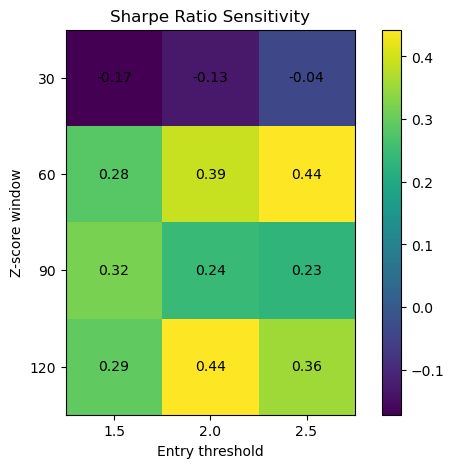

In [69]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(sharpe_pivot.values)

ax.set_xticks(range(len(sharpe_pivot.columns)))
ax.set_xticklabels(sharpe_pivot.columns)

ax.set_yticks(range(len(sharpe_pivot.index)))
ax.set_yticklabels(sharpe_pivot.index)

ax.set_xlabel("Entry threshold")
ax.set_ylabel("Z-score window")
ax.set_title("Sharpe Ratio Sensitivity")

for i in range(sharpe_pivot.shape[0]):
    for j in range(sharpe_pivot.shape[1]):
        value = sharpe_pivot.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.show()

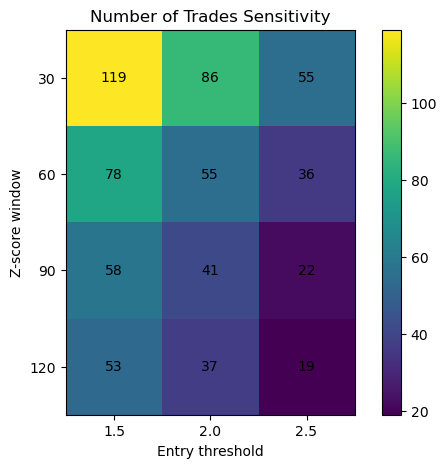

In [72]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(trades_pivot.values)

ax.set_xticks(range(len(trades_pivot.columns)))
ax.set_xticklabels(trades_pivot.columns)

ax.set_yticks(range(len(trades_pivot.index)))
ax.set_yticklabels(trades_pivot.index)

ax.set_xlabel("Entry threshold")
ax.set_ylabel("Z-score window")
ax.set_title("Number of Trades Sensitivity")

for i in range(trades_pivot.shape[0]):
    for j in range(trades_pivot.shape[1]):
        value = trades_pivot.iloc[i, j]
        ax.text(j, i, f"{value:.0f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.show()